# Felix

In [3]:
# 1. Manipulación y Procesamiento de Datos
import pandas as pd
import numpy as np
from scipy import stats
import os

# 2. Preprocesamiento y Transformación de Variables (ML)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 3. Modelado y Algoritmos (Machine Learning y Regresión)
from sklearn.ensemble import IsolationForest     
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
# Importación de los 4 modelos
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  
from sklearn.pipeline import Pipeline

# 4. Visualización de Datos Estática (Informes y Documentación)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 5. Visualización de Datos Interactiva y Modelos 3D (Presentación en clase)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import re

import category_encoders as ce
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# 1. Cargar el dataset desde la carpeta 'data'
df = pd.read_csv('data\\fake_job_postings.csv')


print(f"📊 Tamaño original del dataset: {df.shape}")
print(df.shape)
print(df.head())

📊 Tamaño original del dataset: (17880, 18)
(17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

       

In [4]:
# Eliminar columnas que no aportan información al modelo
columnas_a_eliminar = ['job_id'] # El ID es solo un contador
df = df.drop(columns=columnas_a_eliminar)

In [5]:
# Rellenar nulos en columnas categóricas y de texto
categoricas_y_texto = ['department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col in categoricas_y_texto:
    df[col] = df[col].fillna('Unspecified')

In [6]:
def limpiar_texto(texto):
    if pd.isna(texto) or texto == 'Unspecified':
        return ''
    texto = str(texto).lower() # Todo a minúsculas
    texto = re.sub(r'[^a-z0-9\s]', '', texto) # Quitar caracteres especiales (deja solo letras, números y espacios)
    texto = re.sub(r'\s+', ' ', texto).strip() # Limpiar espacios dobles o saltos de línea
    return texto

# Ejemplo: Aplicar la limpieza a la columna 'description'
df['description_clean'] = df['description'].apply(limpiar_texto)

In [7]:
# Extraer el código del país (los dos primeros caracteres antes de la primera coma)
df['country'] = df['location'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unspecified')

In [8]:
# Ver la distribución de clases
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


In [9]:
# 1. Comprobar que ya no quedan nulos en las columnas que vas a usar
print(df[['title', 'description_clean', 'country', 'fraudulent']].isnull().sum())

# 2. Ver cómo ha quedado una fila real tras la limpieza
print(df['description_clean'].iloc[0][:300]) # Muestra los primeros 300 caracteres de la primera descripción

title                0
description_clean    0
country              0
fraudulent           0
dtype: int64
food52 a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small team of editors executives and developers in its new york city headquartersreproducing andor repackaging existing 


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Configurar el vectorizador para extraer las 500 palabras clave limpias
tfidf = TfidfVectorizer(max_features=500, stop_words='english')

# 2. Aplicar el vectorizador a la columna de texto y guardarlo en la variable X_tfidf
X_tfidf = tfidf.fit_transform(df['description_clean']).toarray()

# 3. Comprobar que se ha creado la matriz correctamente
print("Forma de la matriz de texto:", X_tfidf.shape)

Forma de la matriz de texto: (17880, 500)


In [11]:
# 1. Convertir la matriz TF-IDF en un DataFrame de Pandas
df_tfidf = pd.DataFrame(X_tfidf, columns=[f"txt_{word}" for word in tfidf.get_feature_names_out()])

# Nota: tiene txt al inicio para saber que se saco de la descripcion

# 2. Seleccionar las otras columnas numéricas/binarias que interesan del df original
columnas_numericas = ['telecommuting', 'has_company_logo', 'has_questions']
df_numerico = df[columnas_numericas].reset_index(drop=True)

# 3. Concatenar (juntar de lado) las columnas numéricas y las del texto
X_final = pd.concat([df_numerico, df_tfidf], axis=1)

# 4. Tu variable objetivo (lo que queremos predecir) sigue siendo la misma
y_final = df['fraudulent'].reset_index(drop=True)

# 5. Comprobar las dimensiones finales
print("Dimensiones de las variables predictoras (X):", X_final.shape)
print("Dimensiones de la variable objetivo (y):", y_final.shape)

Dimensiones de las variables predictoras (X): (17880, 503)
Dimensiones de la variable objetivo (y): (17880,)


In [12]:
# Ver las primeras 50 palabras que corresponden a esas 500 columnas
print(tfidf.get_feature_names_out()[:50])

['200' 'ability' 'able' 'account' 'accounting' 'accounts' 'accurate'
 'achieve' 'activities' 'administrative' 'advertising' 'agency' 'agile'
 'amp' 'analysis' 'analytics' 'andor' 'app' 'application' 'applications'
 'apply' 'approach' 'appropriate' 'architecture' 'area' 'areas' 'asia1500'
 'aspects' 'assigned' 'assist' 'assistant' 'attention' 'available'
 'background' 'base' 'based' 'basis' 'believe' 'benefits' 'best' 'better'
 'big' 'brand' 'brands' 'bring' 'build' 'building' 'business' 'businesses'
 'calls']


# **Outliers**

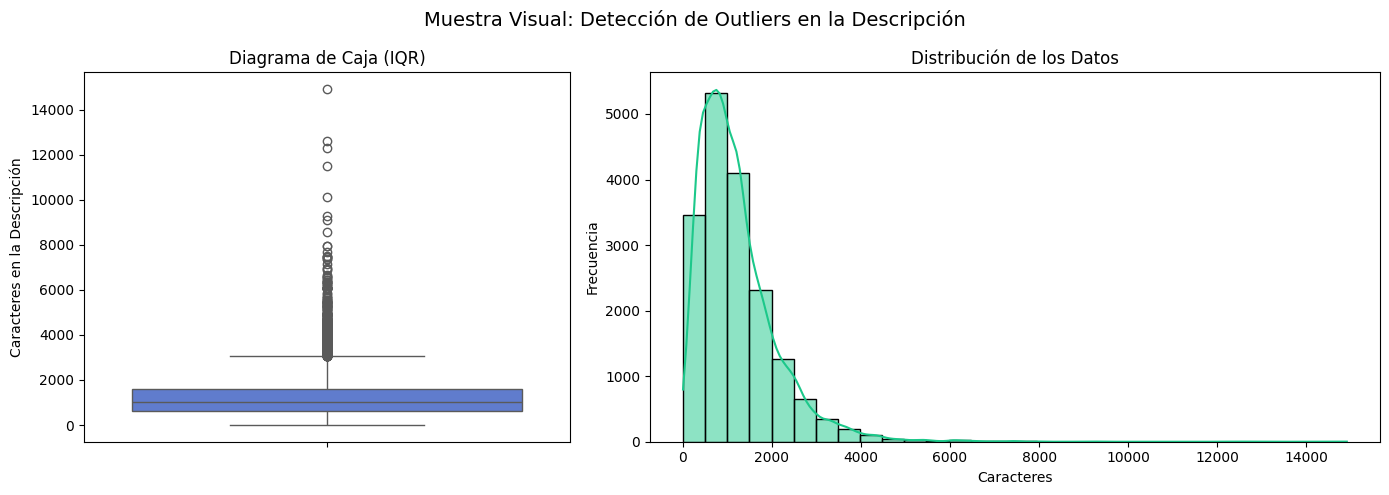

📊 Estadísticas de control:
count    17880.000000
mean      1218.005034
std        894.827787
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: longitud_descripcion, dtype: float64


In [13]:
# Crear la métrica de longitud de texto
df["longitud_descripcion"] = df["description"].fillna("").str.len()

# Configurar gráficos
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": (0.4, 0.6)}
)
fig.suptitle(
    "Muestra Visual: Detección de Outliers en la Descripción", fontsize=14
)

# 1. Boxplot (Muestra los puntos atípicos fuera de los bigotes)
sns.boxplot(ax=ax_box, y=df["longitud_descripcion"], color="#4e73df")
ax_box.set_title("Diagrama de Caja (IQR)")
ax_box.set_ylabel("Caracteres en la Descripción")

# 2. Histograma (Muestra la distribución real)
sns.histplot(
    ax=ax_hist, x=df["longitud_descripcion"], bins=30, kde=True, color="#1cc88a")
ax_hist.set_title("Distribución de los Datos")
ax_hist.set_xlabel("Caracteres")
ax_hist.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Resumen numérico en consola
print("📊 Estadísticas de control:")
print(df["longitud_descripcion"].describe())

In [14]:
total_original = df.shape[0]

# 2. Calcular la métrica temporal
df["_len_desc"] = df["description"].fillna("").str.len()

# 3. Aplicar el filtro del Rango Intercuartílico (IQR)
Q1 = df["_len_desc"].quantile(0.25)
Q3 = df["_len_desc"].quantile(0.75)
IQR = Q3 - Q1

# Definir límites (El estándar es 1.5 veces el IQR)
limite_inferior = max(
    10, Q1 - 1.5 * IQR
)  # Evitamos longitudes negativas, exigimos al menos 10 caracteres
limite_superior = Q3 + 1.5 * IQR

# 4. Filtrar el DataFrame
df_limpio = df[(df["_len_desc"] >= limite_inferior) & (df["_len_desc"] <= limite_superior)].copy()

# Eliminar la columna auxiliar
df_limpio.drop(columns=["_len_desc"], inplace=True)

# 5. Guardar resultados
outliers_eliminados = total_original - df_limpio.shape[0]
print(f"🧹 ¡Limpieza completada!")
print(f"🔹 Filas originales: {total_original}")
print(f"🔹 Outliers eliminados: {outliers_eliminados}")
print(f"🔹 Filas actuales: {df_limpio.shape[0]}")

output_path = os.path.join("data", "fake_job_postings_clean.csv")
df_limpio.to_csv(output_path, index=False)
print(f"💾 Guardado en: {output_path}")

🧹 ¡Limpieza completada!
🔹 Filas originales: 17880
🔹 Outliers eliminados: 727
🔹 Filas actuales: 17153
💾 Guardado en: data\fake_job_postings_clean.csv


## Analisis Univariado

fraudulent
0    17014
1      866
Name: count, dtype: int64


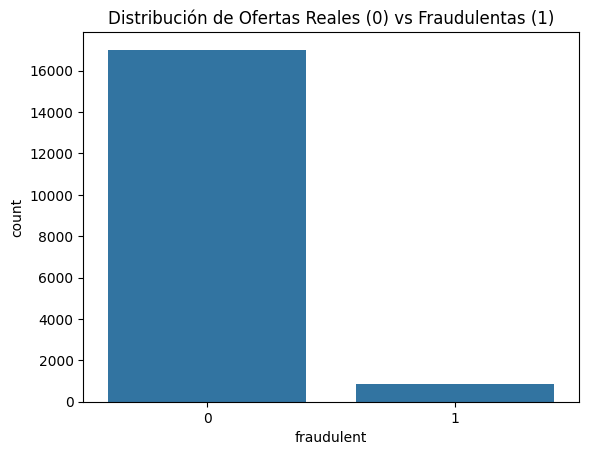

In [15]:
print(df['fraudulent'].value_counts())
sns.countplot(x='fraudulent', data=df)
plt.title('Distribución de Ofertas Reales (0) vs Fraudulentas (1)')
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_14616\4133798167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
C:\Users\felix\AppData\Local\Temp\ipykernel_14616\4133798167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
C:\Users\felix\AppData\Local\Temp\ipykernel_14616\4133798167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')


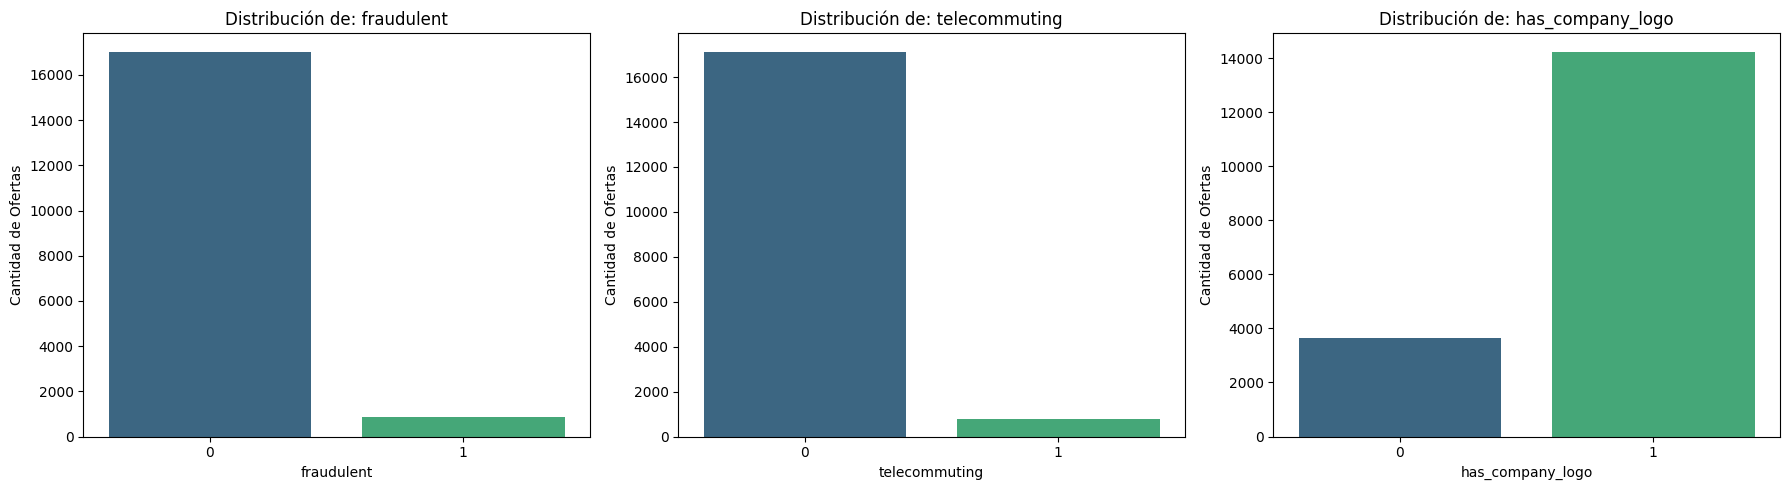

In [16]:
# 1. Definimos las variables binarias reales e interesantes de tu CSV
variables_binarias = ['fraudulent', 'telecommuting', 'has_company_logo']

# 2. Creamos la estructura de los 3 gráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. Ejecutamos el bucle sin que falle por el NameError
for i, col in enumerate(variables_binarias):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Ofertas')

# Ajuste automático para que no se pisen los textos
plt.tight_layout()
plt.show()

required_experience
Unspecified         7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64


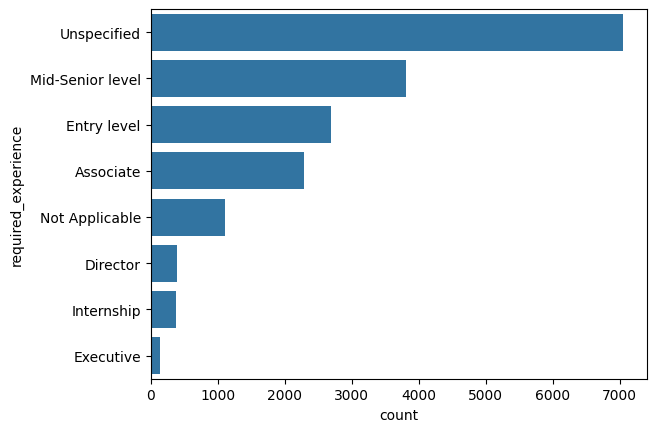

In [17]:
# Ver los valores únicos de la experiencia
print(df['required_experience'].value_counts(dropna=False))

# Gráfico de barras horizontal por si hay muchas categorías
sns.countplot(y='required_experience', data=df, order=df['required_experience'].value_counts().index)
plt.show()

In [18]:
#Creamos una columna que rellenamos donde rellenamos nulos con texto vacío, aseguramos que sea string y medimos la longitud

df['description_length'] = df['description_clean'].str.len().fillna(0)

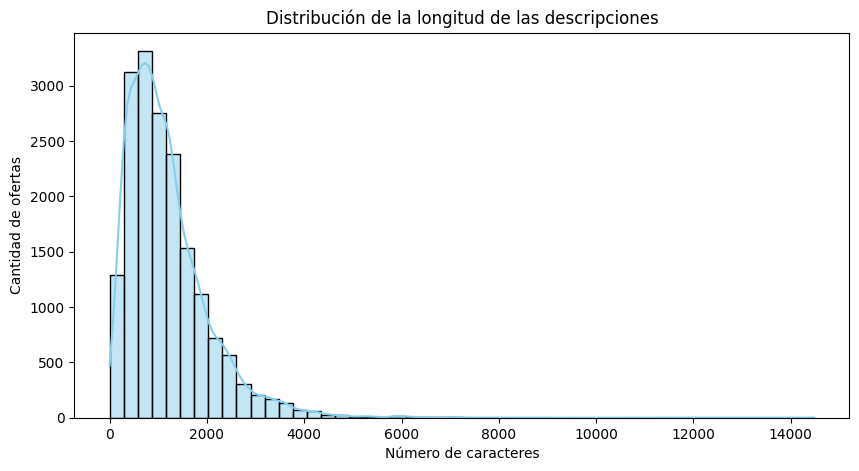

In [19]:
# 2. Pintamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(df['description_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de caracteres')
plt.ylabel('Cantidad de ofertas')
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_14616\3615561882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')


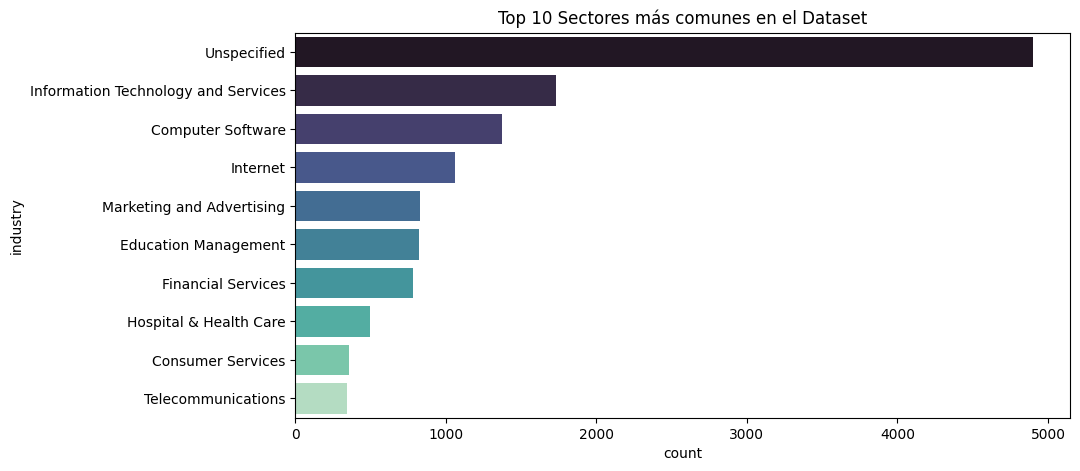

In [20]:
# Ver los 10 sectores con más ofertas de empleo
plt.figure(figsize=(10, 5))
sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')
plt.title('Top 10 Sectores más comunes en el Dataset')
plt.show()

## 📝 Conclusiones del Análisis Univariado

Tras analizar de forma individual las variables clave de nuestro dataset de ofertas de empleo, hemos extraído las siguientes conclusiones fundamentales para el desarrollo del proyecto:

### 1. Desbalanceo Crítico de la Variable Objetivo (`fraudulent`)
* **Hallazgo:** El dataset presenta un desbalanceo masivo. Las ofertas de trabajo fraudulentas representan únicamente alrededor del **5%** del total de los registros, mientras que el 95% restante corresponde a ofertas reales.
* **Impacto en el modelo:** Este desbalanceo nos indica que **no podremos utilizar la métrica de *Accuracy* (Exactitud)** como indicador principal para evaluar nuestros modelos predictivos. Un clasificador básico que prediga siempre "no fraude" obtendría un 95% de acierto pero sería completamente inútil. Deberemos enfocar los esfuerzos en optimizar métricas como el **Recall** (Sensibilidad) y el **F1-Score** para capturar correctamente ese 5% de casos positivos.

### 2. Comportamiento de las Variables Binarias e Indicadores
* **`telecommuting` (Teletrabajo):** La inmensa mayoría de las ofertas publicadas corresponden a puestos presenciales. El trabajo en remoto es una opción muy minoritaria en la distribución general del dataset.
* **`has_company_logo` (Logo de la empresa):** Predominan notablemente las ofertas que sí cuentan con un logotipo de empresa subido a la plataforma, lo que sugiere que la falta de este elemento podría ser una anomalía a investigar.
* **`has_questions` (Preguntas de filtrado):** Existe una distribución bastante equilibrada en el dataset, aunque con una ligera tendencia hacia las ofertas que sí incluyen preguntas de cribado en su formulario de inscripción.

### 3. Distribución Categórica y Concentración de Sectores (`industry`)
* **Hallazgo:** Al analizar el *Top 10* de industrias, el dataset se encuentra fuertemente dominado por el sector de **Tecnología y Servicios de la Información (IT)**, seguido muy de cerca por sectores afines como *Computer Software*, *Internet* y *Financial Services*.
* **Impacto en el modelo:** Al estar la información tan concentrada en perfiles tecnológicos, de desarrollo y oficinas, las dinámicas de fraude que aprenda el modelo estarán estrechamente ligadas al contexto y vocabulario de este sector profesional.

### 4. Características de los Textos Libres (`description_length`)
* **Hallazgo:** La longitud de las descripciones de los puestos sigue una distribución fuertemente asimétrica hacia la derecha (cola larga). Si bien la mayoría de los reclutadores redactan textos extensos y detallados, se detecta un pico anómalo y muy marcado cerca de **0 caracteres** (ofertas que no incluyen apenas texto descriptivo).

### 5. Diagnóstico de Datos Faltantes (Nulos)
* **Hallazgo:** El dataset presenta graves ausencias de información en columnas críticas. La variable `salary_range` (rango salarial) es la que acumula el mayor volumen de nulos con diferencia, seguida por `department`. Otras variables como `required_education` e `industry` también muestran pérdidas notables de datos.


## Regresion

In [21]:
df_clean=pd.read_csv('data\\fake_job_postings_clean.csv')

In [22]:
print(df_clean.columns.tolist())

['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'description_clean', 'country', 'longitud_descripcion']


In [ ]:
import category_encoders as ce
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. PALABRAS CLAVE ESTRATÉGICAS PARA DETECTAR FRAUDE (VOCABULARIO FIJO)
# =====================================================================
# Definimos exactamente qué palabras rastrear. Cada palabra será 1 columna física.
palabras_clave_fraude = [
    "urgent",
    "money",
    "investment",
    "wire",
    "transfer",
    "cash",
    "bitcoin",
    "crypto",
    "deposit",
    "fee",
    "online",
    "unspecified",
    "guaranteed",
    "income",
    "weekly",
    "earn",
    "bonus",
    "risk",
    "immediate",
    "start",
    "secret",
    "shopper",
    "representative",
]

# Configurando TF-IDF con tu vocabulario personalizado
# Esto garantiza que el texto genere EXACTAMENTE 23 columnas muy informativas
tfidf = TfidfVectorizer(vocabulary=palabras_clave_fraude, stop_words="english")


# =====================================================================
# 2. SEPARACIÓN INICIAL DE VARIABLES
# =====================================================================
objetivo = df_clean["fraudulent"]

# Eliminamos todas las columnas de texto masivo y variables objetivo antiguas
columnas_a_borrar = [
    "fraudulent",
    "title",
    "company_profile",
    "requirements",
    "benefits",
    "description_clean",  # Borramos la limpia ya que usaremos "description" para el vectorizer
]
X_original = df_clean.drop(columns=columnas_a_borrar, errors="ignore")

# Dividimos en Train y Validation protegiendo contra fugas de datos (Target encoding seguro)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_original, objetivo, test_size=0.2, random_state=42, stratify=objetivo
)


# =====================================================================
# 3. EXTRAER COLUMNAS DE PALABRAS CLAVE (TF-IDF CONTROLADO)
# =====================================================================
# Transformamos basándonos estrictamente en la lista de arriba
tfidf_train = tfidf.fit_transform(X_train_raw["description"].fillna(""))
tfidf_val = tfidf.transform(X_val_raw["description"].fillna(""))

df_tfidf_train = pd.DataFrame(
    tfidf_train.toarray(),
    columns=[f"key_{word}" for word in palabras_clave_fraude],
    index=X_train_raw.index,
)
df_tfidf_val = pd.DataFrame(
    tfidf_val.toarray(),
    columns=[f"key_{word}" for word in palabras_clave_fraude],
    index=X_val_raw.index,
)

# Ahora sí podemos remover la columna de texto libre "description" sin peligro
X_train_clean = X_train_raw.drop(columns=["description"], errors="ignore")
X_val_clean = X_val_raw.drop(columns=["description"], errors="ignore")


# =====================================================================
# 4. TARGET ENCODING DE CATEGORÍAS (industry, department, country, etc.)
# =====================================================================
# Identificamos el resto de variables de texto que no son descripción
columnas_categoricas = (
    X_train_clean.select_dtypes(include=["object", "category"]).columns.tolist()
)

# Aplicamos el Target Encoder para compactar todo sin One-Hot
encoder = ce.TargetEncoder(cols=columnas_categoricas)
X_train_encoded = encoder.fit_transform(X_train_clean, y_train)
X_val_encoded = encoder.transform(X_val_clean)


# =====================================================================
# 5. ENSAMBLAJE FINAL DE LOS DATAFRAMES
# =====================================================================
X_train_final = pd.concat([X_train_encoded, df_tfidf_train], axis=1)
X_val_final = pd.concat([X_val_encoded, df_tfidf_val], axis=1)

print("--- 🏁 ¡Estrategia por Palabras Clave y Codificación Completada! ---")
print(
    f"Dimensiones de Entrenamiento: {X_train_final.shape[0]} filas, {X_train_final.shape[1]} columnas."
)
print(
    f"Dimensiones de Validación: {X_val_final.shape[0]} filas, {X_val_final.shape[1]} columnas."
)
print(
    f"\nColumnas de texto creadas por tus palabras clave:\n{list(df_tfidf_train.columns)}"
)

KeyError: 'SalePrice'

In [24]:
# 1. DIVISIÓN EN ENTRENAMIENTO (80%) Y VALIDACIÓN (20%)
# Usamos stratify=y porque la variable fraude está muy desbalanceada
X_train, X_val, y_train, y_val = train_test_split(
    X_codificado, objetivo, test_size=0.2, random_state=42, stratify=objetivo
)

# 2. IDENTIFICAR LAS COLUMNAS NUMÉRICAS CONTINUAS
# Solo queremos escalar columnas como 'longitud_descripcion' (que tienen muchos valores únicos)
columnas_a_escalar = [col for col in X_train.columns if X_train[col].nunique() > 2]

# 3. CONFIGURAR EL ESCALADOR
scaler = StandardScaler()

# 4. AJUSTAR Y TRANSFORMAR LOS DATOS
X_train_escalado = X_train.copy()
X_val_escalado = X_val.copy()

# Si hay columnas numéricas continuas, las escalamos
if columnas_a_escalar:
    X_train_escalado[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
    X_val_escalado[columnas_a_escalar] = scaler.transform(X_val[columnas_a_escalar])

print("--- ⚖️ División y Escalamiento Completado (Detección de Fraude) ---")
print(f"Tamaño del set de Entrenamiento (X_train): {X_train_escalado.shape[0]} ofertas de empleo.")
print(f"Tamaño del set de Validación (X_val): {X_val_escalado.shape[0]} ofertas de empleo.")

NameError: name 'X_codificado' is not defined

In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score

# 1. INSTANCIAR LOS CUATRO MODELOS PARA CLASIFICACIÓN
# Usamos class_weight='balanced' o parámetros de escala para manejar el desbalance de fraudes
modelo_log = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_gb = GradientBoostingClassifier(random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42
)


# 2. FUNCIÓN REUTILIZABLE PARA EVALUAR CADA MODELO (Enfoque Clasificación)
def evaluar_modelo(modelo, X_t, y_t, X_v, y_v):
    # Entrenar el modelo
    modelo.fit(X_t, y_t)

    # Predecir probabilidades para el ROC-AUC
    prob_train = modelo.predict_proba(X_t)[:, 1]
    prob_val = modelo.predict_proba(X_v)[:, 1]
    
    # Predecir clases (0 o 1) para el F1-Score
    pred_val = modelo.predict(X_v)

    # Calcular las métricas finales
    auc_train = roc_auc_score(y_t, prob_train)
    auc_val = roc_auc_score(y_v, prob_val)
    f1_val = f1_score(y_v, pred_val)
    overfitting = (auc_train - auc_val) * 100

    return auc_train, auc_val, overfitting, f1_val


from sklearn.preprocessing import StandardScaler

# 1. Creamos los datos escalados que te está pidiendo el torneo
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train_final)
X_val_escalado = scaler.transform(X_val_final)

# 2. Ahora ya puedes ejecutar tu bloque de entrenamiento sin errores:
m_log = evaluar_modelo(modelo_log, X_train_escalado, y_train, X_val_escalado, y_val)
m_gb = evaluar_modelo(modelo_gb, X_train_escalado, y_train, X_val_escalado, y_val)
m_rf = evaluar_modelo(modelo_rf, X_train_escalado, y_train, X_val_escalado, y_val)
m_xgb = evaluar_modelo(modelo_xgb, X_train_escalado, y_train, X_val_escalado, y_val)

# 4. CONSTRUIR LA TABLA COMPARATIVA FINAL
tabla_completa = pd.DataFrame(
    {
        "Modelo": ["Regresión Logística", "Gradient Boosting", "Random Forest", "XGBoost"],
        "ROC-AUC Train": [m_log[0], m_gb[0], m_rf[0], m_xgb[0]],
        "ROC-AUC Validation": [m_log[1], m_gb[1], m_rf[1], m_xgb[1]],
        "Brecha Overfitting": [
            f"{m_log[2]:.2f}%",
            f"{m_gb[2]:.2f}%",
            f"{m_rf[2]:.2f}%",
            f"{m_xgb[2]:.2f}%",
        ],
        "F1-Score Validation": [m_log[3], m_gb[3], m_rf[3], m_xgb[3]],
    }
)

print("\n--- 🏁 ¡Torneo de Clasificación (Fraude) Finalizado! ---")
display(tabla_completa.round(4))


--- 🏁 ¡Torneo de Clasificación (Fraude) Finalizado! ---


,Modelo,ROC-AUC Train,ROC-AUC Validation,Brecha Overfitting,F1-Score Validation
0,Regresión Logística,0.9811,0.9547,2.64%,0.5292
1,Gradient Boosting,0.9959,0.9553,4.06%,0.6400
2,Random Forest,0.9995,0.9683,3.12%,0.6597
3,XGBoost,0.9957,0.9582,3.75%,0.6406
